In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Environment working!
Pandas: 3.0.6
NumPy: 2.5.3


In [2]:
import pandas as pd

df = pd.read_csv("../Data/train.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 9800
Columns: 18


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [4]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows: 0


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Date range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [8]:
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Date", "Sales"]

print("Number of months:", len(monthly_sales))
monthly_sales.head(10)

Number of months: 48


,Date,Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


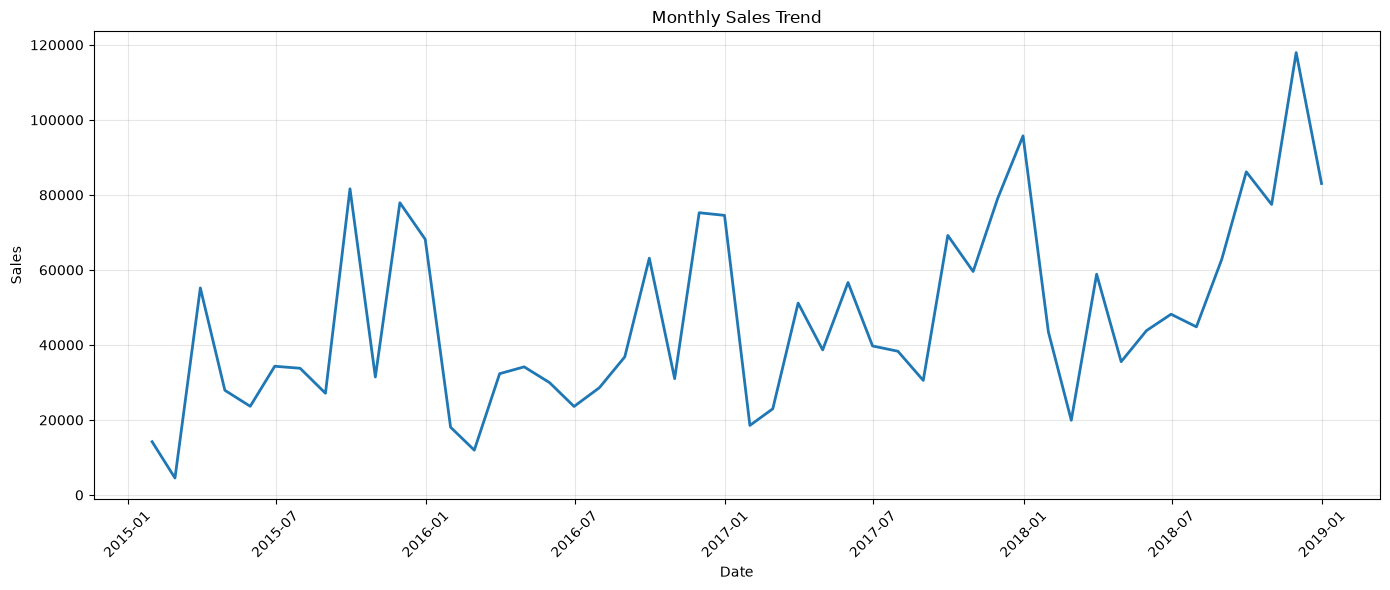

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
monthly_seasonality = (
    monthly_sales.assign(
        Month=monthly_sales["Date"].dt.month,
        Month_Name=monthly_sales["Date"].dt.strftime("%B")
    )
    .groupby(["Month", "Month_Name"])["Sales"]
    .mean()
    .reset_index()
    .sort_values("Month")
)

monthly_seasonality

,Month,Month_Name,Sales
0,1,January,23572.907400
1,2,February,14842.778850
2,3,March,49393.396800
3,4,April,34070.750150
4,5,May,38521.680925
5,6,June,36459.380825
6,7,July,36383.922250
7,8,August,39328.981750
8,9,September,75025.852925
9,10,October,49874.073675


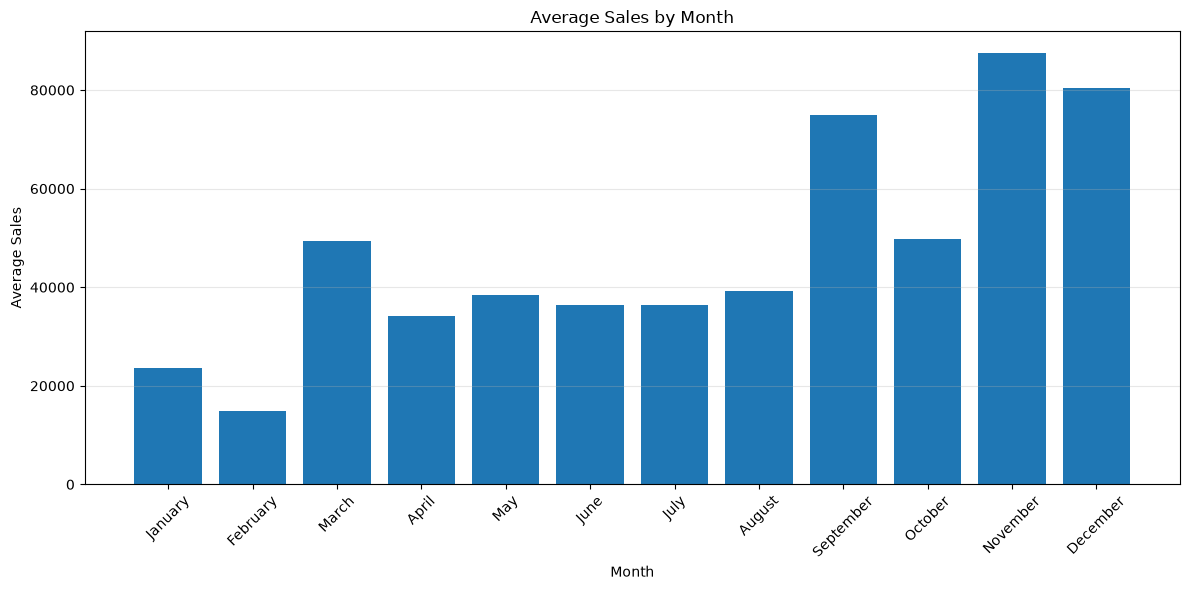

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_seasonality["Month_Name"],
    monthly_seasonality["Sales"]
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
train = monthly_sales.iloc[:-12].copy()
test = monthly_sales.iloc[-12:].copy()

print("Training period:", train["Date"].min(), "to", train["Date"].max())
print("Testing period:", test["Date"].min(), "to", test["Date"].max())

print("\nTraining months:", len(train))
print("Testing months:", len(test))

Training period: 2015-01-31 00:00:00 to 2017-12-31 00:00:00
Testing period: 2018-01-31 00:00:00 to 2018-12-31 00:00:00

Training months: 36
Testing months: 12


In [13]:
baseline = test.copy()

baseline["Forecast"] = train["Sales"].iloc[-12:].values

baseline.head(12)

,Date,Sales,Forecast
36,2018-01-31,43476.4740,18542.4910
37,2018-02-28,19920.9974,22978.8150
38,2018-03-31,58863.4128,51165.0590
39,2018-04-30,35541.9101,38679.7670
40,2018-05-31,43825.9822,56656.9080
41,2018-06-30,48190.7277,39724.4860
42,2018-07-31,44825.1040,38320.7830
43,2018-08-31,62837.8480,30542.2003
44,2018-09-30,86152.8880,69193.3909
45,2018-10-31,77448.1312,59583.0330


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_baseline = mean_absolute_error(
    baseline["Sales"],
    baseline["Forecast"]
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        baseline["Sales"],
        baseline["Forecast"]
    )
)

mape_baseline = (
    np.mean(
        np.abs(
            (baseline["Sales"] - baseline["Forecast"])
            / baseline["Sales"]
        )
    ) * 100
)

print(f"Baseline MAE:  {mae_baseline:,.2f}")
print(f"Baseline RMSE: {rmse_baseline:,.2f}")
print(f"Baseline MAPE: {mape_baseline:.2f}%")

Baseline MAE:  15,444.18
Baseline RMSE: 18,932.10
Baseline MAPE: 24.86%


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

ets_forecast = ets_model.forecast(12)

print(ets_forecast)

36    30749.776640
37    28837.060023
38    59744.752335
39    50389.272971
40    55462.599559
41    49261.120383
42    52111.227735
43    51664.186423
44    92409.143203
45    58857.927050
46    99101.540214
47    99059.100953
dtype: float64


In [16]:
ets_results = test.copy()
ets_results["Forecast"] = ets_forecast.values

mae_ets = mean_absolute_error(
    ets_results["Sales"],
    ets_results["Forecast"]
)

rmse_ets = np.sqrt(
    mean_squared_error(
        ets_results["Sales"],
        ets_results["Forecast"]
    )
)

mape_ets = (
    np.mean(
        np.abs(
            (ets_results["Sales"] - ets_results["Forecast"])
            / ets_results["Sales"]
        )
    ) * 100
)

print(f"ETS MAE:  {mae_ets:,.2f}")
print(f"ETS RMSE: {rmse_ets:,.2f}")
print(f"ETS MAPE: {mape_ets:.2f}%")

ETS MAE:  10,687.50
ETS RMSE: 12,157.49
ETS MAPE: 20.55%


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=12)

print(sarima_forecast)

36     27975.796264
37     34827.155923
38     63496.319662
39     49788.562537
40     68264.672591
41     51284.731174
42     49491.182792
43     40827.461374
44     80801.967301
45     71137.522359
46     90369.066812
47    107464.423771
Name: predicted_mean, dtype: float64


d:\Portfolio\Sales_Forecasting_Predictive_Analytics\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


In [18]:
sarima_results = test.copy()
sarima_results["Forecast"] = sarima_forecast.values

mae_sarima = mean_absolute_error(
    sarima_results["Sales"],
    sarima_results["Forecast"]
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        sarima_results["Sales"],
        sarima_results["Forecast"]
    )
)

mape_sarima = (
    np.mean(
        np.abs(
            (sarima_results["Sales"] - sarima_results["Forecast"])
            / sarima_results["Sales"]
        )
    ) * 100
)

print(f"SARIMA MAE:  {mae_sarima:,.2f}")
print(f"SARIMA RMSE: {rmse_sarima:,.2f}")
print(f"SARIMA MAPE: {mape_sarima:.2f}%")

SARIMA MAE:  13,930.02
SARIMA RMSE: 16,394.82
SARIMA MAPE: 27.77%


In [19]:
model_comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "ETS",
        "SARIMA"
    ],
    "MAE": [
        mae_baseline,
        mae_ets,
        mae_sarima
    ],
    "RMSE": [
        rmse_baseline,
        rmse_ets,
        rmse_sarima
    ],
    "MAPE (%)": [
        mape_baseline,
        mape_ets,
        mape_sarima
    ]
})

model_comparison

,Model,MAE,RMSE,MAPE (%)
0,Seasonal Naive,15444.177850,18932.101376,24.864669
1,ETS,10687.503669,12157.490652,20.554334
2,SARIMA,13930.017295,16394.816724,27.768090


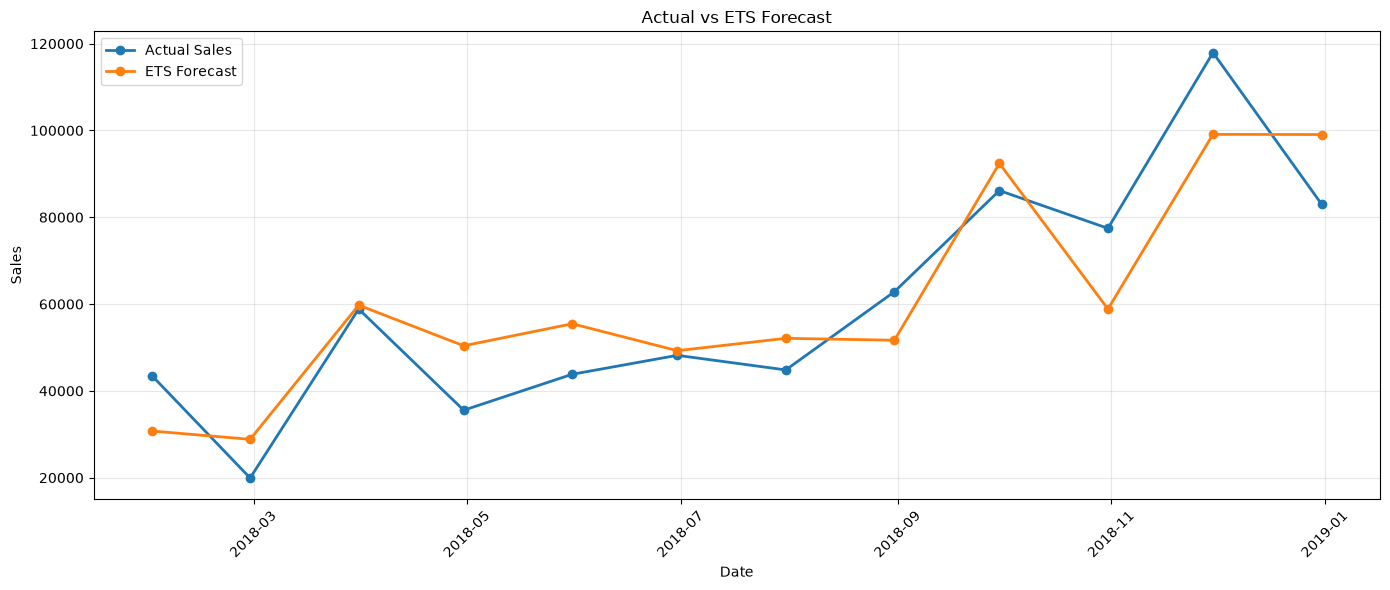

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    test["Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    ets_results["Forecast"],
    marker="o",
    linewidth=2,
    label="ETS Forecast"
)

plt.title("Actual vs ETS Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

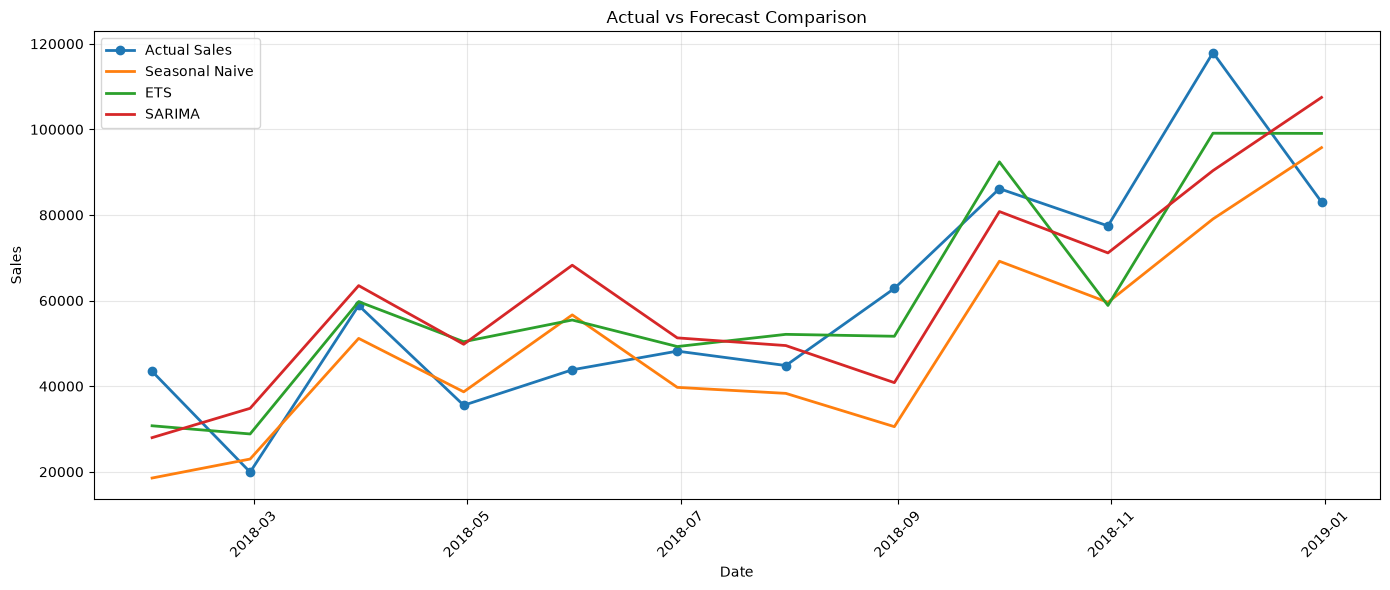

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["Date"],
    test["Sales"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    test["Date"],
    baseline["Forecast"],
    linewidth=2,
    label="Seasonal Naive"
)

plt.plot(
    test["Date"],
    ets_results["Forecast"],
    linewidth=2,
    label="ETS"
)

plt.plot(
    test["Date"],
    sarima_results["Forecast"],
    linewidth=2,
    label="SARIMA"
)

plt.title("Actual vs Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
final_ets_model = ExponentialSmoothing(
    monthly_sales["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

future_forecast = final_ets_model.forecast(12)

future_dates = pd.date_range(
    start=monthly_sales["Date"].max() + pd.offsets.MonthEnd(1),
    periods=12,
    freq="ME"
)

future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Sales": future_forecast.values
})

future_forecast_df

,Date,Forecast_Sales
0,2019-01-31,49392.896673
1,2019-02-28,41600.086865
2,2019-03-31,71943.163585
3,2019-04-30,60875.812897
4,2019-05-31,68134.269477
5,2019-06-30,62708.329932
6,2019-07-31,66240.788761
7,2019-08-31,65234.819894
8,2019-09-30,105703.376416
9,2019-10-31,76598.168464


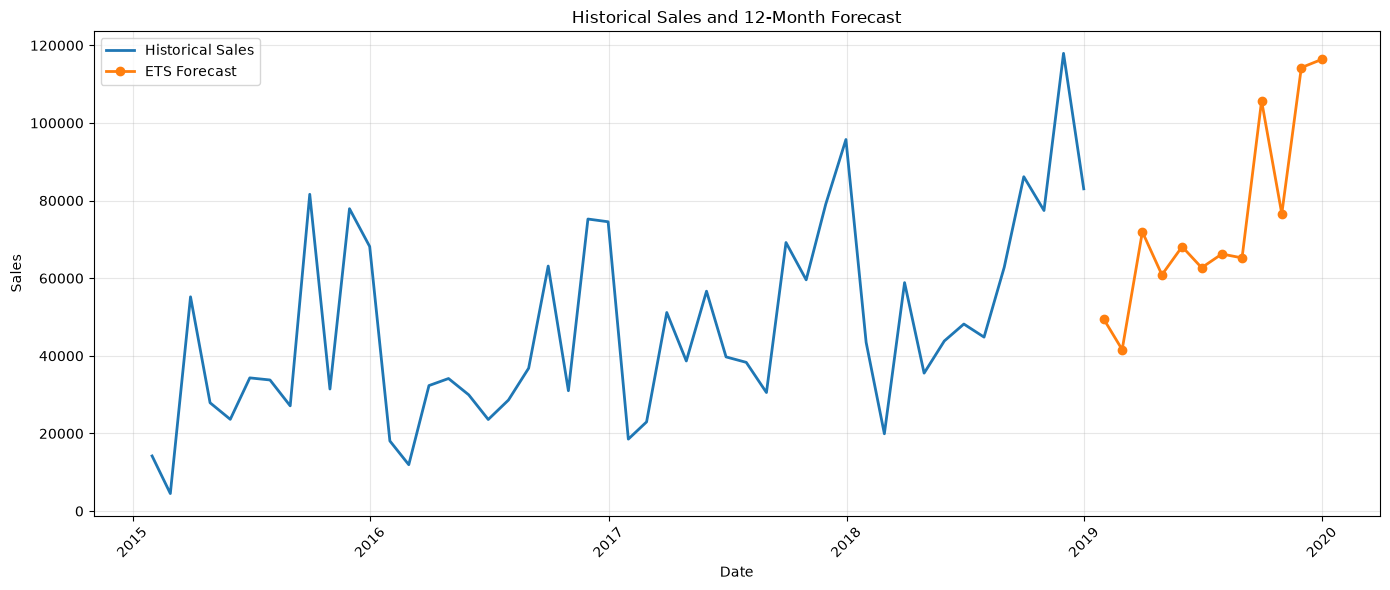

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    linewidth=2,
    label="Historical Sales"
)

plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecast_Sales"],
    marker="o",
    linewidth=2,
    label="ETS Forecast"
)

plt.title("Historical Sales and 12-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
future_forecast_df.to_csv(
    "../PowerBI/future_sales_forecast.csv",
    index=False
)

model_comparison.to_csv(
    "../PowerBI/model_comparison.csv",
    index=False
)

print("Forecast and model comparison exported successfully.")

Forecast and model comparison exported successfully.


In [1]:
monthly_sales.to_csv(
    "../PowerBI/historical_monthly_sales.csv",
    index=False
)

print("Historical monthly sales exported successfully.")

NameError: name 'monthly_sales' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../Data/train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.columns = ["Date", "Sales"]

monthly_sales.to_csv(
    "../PowerBI/historical_monthly_sales.csv",
    index=False
)

print("Historical monthly sales exported successfully.")
print(monthly_sales.head())

Historical monthly sales exported successfully.
        Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
